In [ ]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import plotting_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

import diagnostic_utils

importlib.reload(diagnostic_utils)

<module 'diagnostic_utils' from '/home/emily_zuetell/projects/poreallas/analysis/diagnostic_utils.py'>

In [3]:
load_dotenv()

EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_PARSED_FORECAST_URI"]

In [ ]:
# Projection Effects
load_dotenv()
# Baseline period for Impact
effect = xr.open_datatree(EFFECTS_URI, consolidated=False)
BASELINE_PERIOD = analysis_utils.get_baseline_period(effect, years=30)
# Define Forecast Months
FC_MONTHS = [9, 10, 11, 12, 1, 2]
FC_PERIOD = slice("2026-09-01", "2027-02-28")

config = analysis_utils.ImpactConfig( version = "v260910",
                                     baseline_period=BASELINE_PERIOD, 
                                     polygons_path= os.environ["POREALLAS_REGIONS_POLYGONS_URI"],
                                     socioeconomics_path= os.environ["POREALLAS_SOCIOECONOMICS_URI"],
                                     rate=True, 
                                     months = FC_MONTHS,
                                     hotonly = "net", 
                                     age_weight= False,
                                     dims = ['number', 'sample'])

In [8]:
### TEST DATA ###
# IR Climate Data
forecast = xr.open_zarr(TAS_FORECAST_URI) - 273.15
# Gridded to Impact Region
forecast_ir = isku_utils.grid_to_ir(forecast, savefile=None)

era5 = (
    xr.open_zarr(ERA5_URI).sel(
        time=slice("1996-01-01", "2025-12-31")
    )
    - 273.15
)
era5_ir = isku_utils.grid_to_ir(era5, savefile=None)
era5_ir = era5_ir.assign_coords(month=era5_ir["time"].dt.month)

betas_mmt = effect['/fixed_beta']

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

In [11]:
### Analysis Options ###
density_hist = False  # Controls daily data histograms (not computation normalization)

### Region Selection ###
region_filters = [
    "PAK.2.5.27",
    "IND.16.203.735",
    "BRA.7.804.1862",
    "IND.29.439.1743",
    "CHN.11.109.767",  # set to None for global
    "COD.3.15.51",
    "THA.76.909.5787",
    "HRV.R4acd3465906d6fba",
    "EGY.8",
    "BRA.9.R7ae8d9b7a4e0454f",
    "ZMB.9.67",
    "USA.14.608",
]

region_filter = "MOZ.8.Ra1718841d5afe6a8"

# Compute Impact
projected = effect
impact = analysis_utils.compute_impact(effect.chunk({dim: -1 for dim in config.dims}), 
                                        config,
                                        ensemble=True)

# Get Months
months = config.months

### Load Climate Data ###
# Select representative ensemble member
forecast_slice = forecast_ir["tas"].sel(number=1)
forecast_local = forecast_slice.sel(region=region_filter)

# Select representative year
reanalysis_slice = era5_ir["tas"].sel(time=slice("2000-01-01", "2000-12-31"))
month_mask = reanalysis_slice.month.isin(months).compute()
reanalysis_slice = reanalysis_slice.where(month_mask, drop=True)
reanalysis_local = reanalysis_slice.sel(region=region_filter)

combined = np.concat(
    [forecast_local.values.flatten(), reanalysis_local.values.flatten()]
)
xmin, xmax = np.percentile(combined, [0, 100])
xmin = xmin-3
xmax = xmax+3

# Compute Cumulative Effect
cdf_data, max_cdf = diagnostic_utils.compute_cumulative_effect(
    forecast_slice, 
    reanalysis_slice, 
    region_filter, 
    months, 
    betas_mmt.sel(sample=7),
    hotonly=config.hotonly
)

NameError: name '_polygons' is not defined

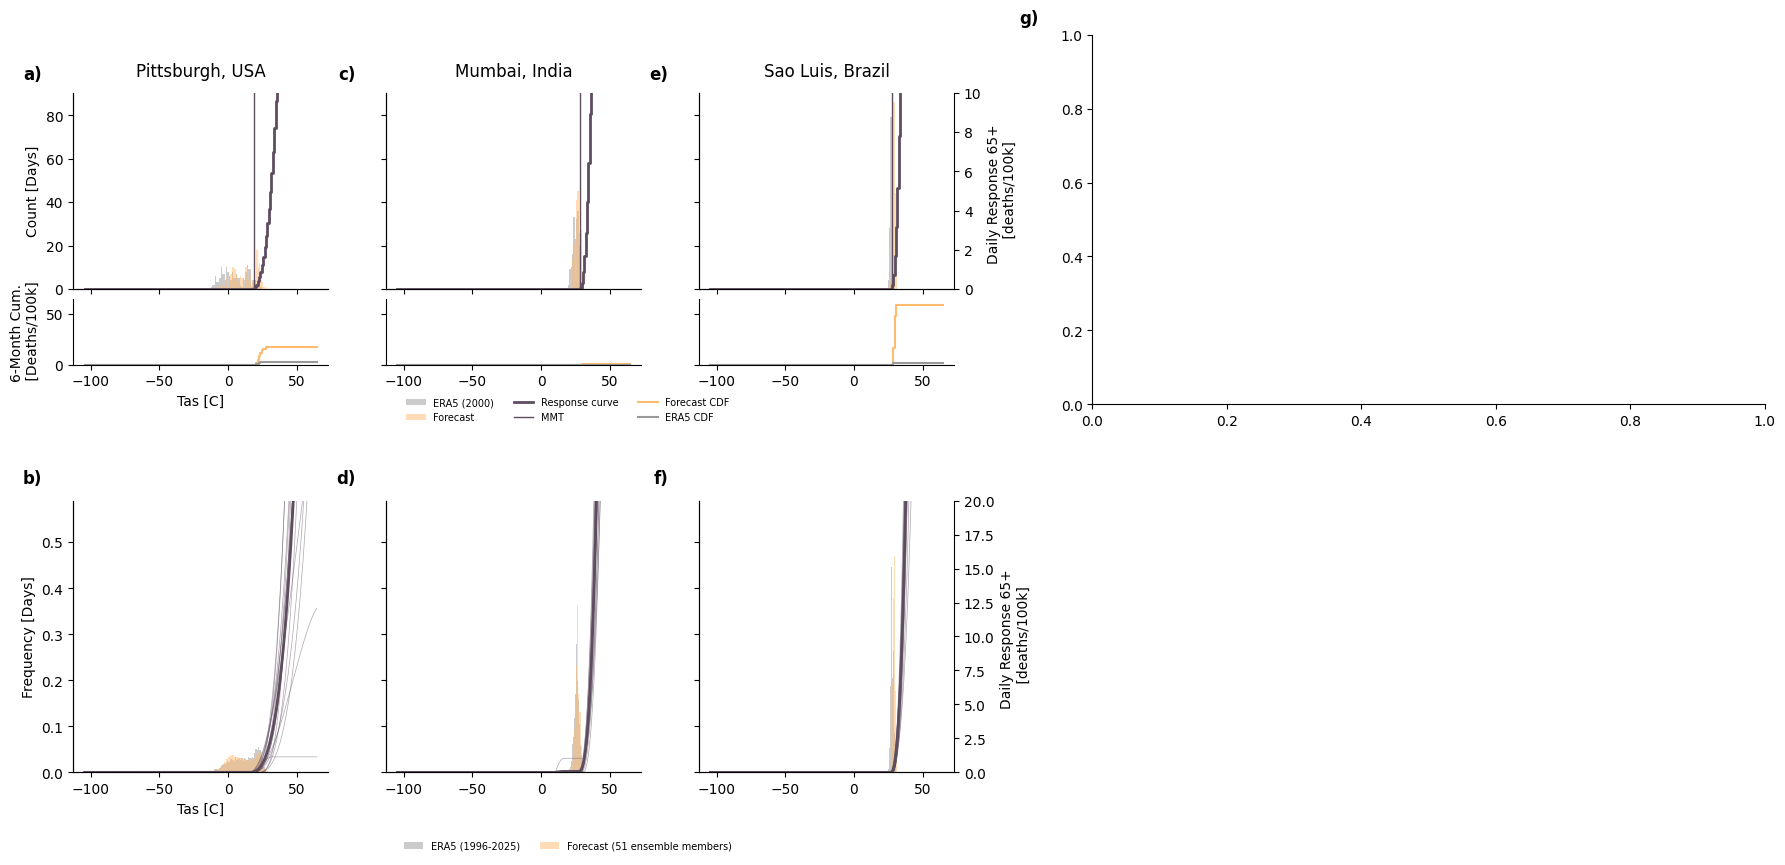

In [ ]:
fig = plt.figure(figsize=(22, 12), constrained_layout=False)
gs_top = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 3], wspace=0.15)

### Select Regions ###
region_ids = ["USA.39.2250", "IND.21.317.1249", "BRA.10.1311.2704"]
region_titles = {
    "USA.39.2250": "Pittsburgh, USA",
    "IND.21.317.1249": "Mumbai, India",
    "BRA.10.1311.2704": "Sao Luis, Brazil",
}

### Select Single Members ###
member = 1
year = slice("2000-01-01", "2000-12-31")
gamma_sample = 7


# Select a single year and ensemble member
forecast_slice = forecast_ir["tas"].sel(number=member)

reanalysis_slice = era5_ir["tas"].sel(time=year)
#Select only months in forecast
month_mask = reanalysis_slice.month.isin(months).compute()
reanalysis_slice = reanalysis_slice.where(month_mask, drop=True)
# Load Response Curve
betas = betas_mmt["beta_hotonly"] if config.hotonly == "hotonly" else betas_mmt["beta"]
betas_sample = betas.sel(sample=gamma_sample)
# Load MMT
ref_vals = betas_mmt["mmt"].sel(age_cohort="age65plus")
ref_vals = ref_vals.sel(sample=7)

panel_labels = [("a)", "b)"), ("c)", "d)"), ("e)", "f)")]

### Set Colors ###
b_color = "#999999"
f_color = "#ffbb6f"
r_color = "#5e4c5f"

axes_by_region = {}

handles_top, labels_top = None, None
handles_bottom, labels_bottom = None, None

# Loop through regions
for col, region_filter in enumerate(region_ids):
    # Set up gridspec
    gs_outer_padded = gs_top[col].subgridspec(3, 1, height_ratios=[0.1, 1, 0.1])
    gs_outer = gs_outer_padded[1].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.5)
    gs_inner = gs_outer[0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)

    ax_hist = fig.add_subplot(gs_inner[0])
    ax_cdf = fig.add_subplot(gs_inner[1], sharex=ax_hist)
    ax_hist.tick_params(labelbottom=False)

    ax = fig.add_subplot(gs_outer[1])

    for a in (ax_hist, ax_cdf, ax):
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    ax_hist.text(
        -0.12, 1.05, panel_labels[col][0],
        transform=ax_hist.transAxes,
        fontsize=12, fontweight="bold", va="bottom", ha="right",
    )
    ax.text(
        -0.12, 1.05, panel_labels[col][1],
        transform=ax.transAxes,
        fontsize=12, fontweight="bold", va="bottom", ha="right",
    )

    axes_by_region[region_filter] = {"ax_hist": ax_hist, "ax_cdf": ax_cdf, "ax": ax}

    if col != 0:
        ax_hist.tick_params(labelleft=False)
        ax_cdf.tick_params(labelleft=False)
        ax.tick_params(labelleft=False)

    ### Load Climate Data ###

    # Apply region filter
    forecast_local = forecast_slice.sel(region=region_filter)
    reanalysis_local = reanalysis_slice.sel(region=region_filter)

    # Compute total x-axis bounds
    combined = np.concat(
        [forecast_local.values.flatten(), reanalysis_local.values.flatten()]
    )
    xmin, xmax = np.percentile(combined, [0, 100])
    xmin = xmin - 3
    xmax = xmax + 3

    # Compute CDF
    cdf_data, max_cdf = diagnostic_utils.compute_cumulative_effect(
        forecast_slice, 
        reanalysis_slice, 
        region_filter, 
        months, 
        betas_mmt.sel(sample=7),
        hotonly=config.hotonly
    )

    ### Top Plot: Single Histogram and CDF for each region ###
    ref_vals_local = ref_vals.sel(region=region_filter)

    da_temp_bins_sample = betas_sample.sel(region=region_filter).sel(age_cohort="age65plus")
    da_temp_bins = betas.sel(region=region_filter).sel(age_cohort="age65plus")

    #Consistently set bins as temp bins
    bins = da_temp_bins_sample.coords["tas_bin"]

    ax_hist.hist(
        reanalysis_local.values.flatten(),
        bins=bins,
        alpha=0.5,
        label="ERA5 (2000)",
        density=density_hist,
        color=b_color,
    )
    ax_hist.hist(
        forecast_local.values.flatten(),
        bins=bins,
        alpha=0.5,
        label="Forecast",
        density=density_hist,
        color=f_color,
    )
    ax_hist.set_xlim(xmin, xmax)
    ax_hist.set_title(region_titles[region_filter], pad=12)

    #nPlot response curve (stepped)
    ax_hist2 = ax_hist.twinx()
    ax_hist2.step(
        da_temp_bins_sample.coords["tas_bin"],
        da_temp_bins_sample.values,
        where="pre",
        color=r_color,
        linewidth=2,
        label="Response curve",
    )
    ax_hist2.axvline(ref_vals_local.values, color=r_color, linewidth=1, label="MMT")
    ax_hist2.set_ylim(0, 10)
    ax_hist2.spines["top"].set_visible(False)
    if col != len(region_ids) - 1:
        ax_hist2.tick_params(right=False, labelright=False)
        ax_hist2.spines["right"].set_visible(False)

    ### CDF Plot ###
    era5_centers, era5_cdf, fc_centers, fc_cdf = cdf_data

    ax_cdf.set_ylim(0, max_cdf * 1.1)
    ax_cdf.step(fc_centers, fc_cdf, where="post", color=f_color, label="Forecast CDF")
    ax_cdf.step(era5_centers, era5_cdf, where="post", color=b_color, label="ERA5 CDF")

    if col == 0:
        handles_top = sum((a.get_legend_handles_labels()[0] for a in (ax_hist, ax_hist2, ax_cdf)), [])
        labels_top = sum((a.get_legend_handles_labels()[1] for a in (ax_hist, ax_hist2, ax_cdf)), [])

    ## Lower Plot (Uncertainty)
    forecast_full = forecast_ir["tas"].sel(region=region_filter)
    era5_full = era5_ir["tas"].sel(region=region_filter)

    bins = 50 # make bins more flexible
    ax.hist(
        era5_full.values.flatten(),
        bins=bins,
        alpha=0.5,
        label="ERA5 (1996-2025)",
        density=True,
        color=b_color,
    )
    ax.hist(
        forecast_full.values.flatten(),
        bins=bins,
        alpha=0.5,
        label="Forecast (51 ensemble members)",
        density=True,
        color=f_color,
    )

    ax_bottom2 = ax.twinx()
    # Plot response curves
    for sample in range(0, 15):
        ax_bottom2.plot(
            da_temp_bins.coords["tas_bin"],
            da_temp_bins.sel(sample=sample).values,
            color=r_color,
            linewidth=0.5,
            alpha=0.5,
        )
    
    #Mean Curve
    ax_bottom2.plot(
        da_temp_bins.coords["tas_bin"],
        da_temp_bins.mean(dim='sample').values,
        color=r_color,
        linewidth=2,
        label="Response curve",
    )
    ax_bottom2.set_ylim(0, 20)
    ax_bottom2.spines["top"].set_visible(False)
    if col != len(region_ids) - 1:
        ax_bottom2.tick_params(right=False, labelright=False)
        ax_bottom2.spines["right"].set_visible(False)

    # Shared labels: only outer columns 
    if col == 0:
        ax_hist.set_ylabel("Count [Days]")
        ax_cdf.set_ylabel("6-Month Cum.\n [Deaths/100k]")
        ax.set_ylabel("Frequency [Days]")

    if col == len(region_ids) - 1:
        ax_hist2.set_ylabel("Daily Response 65+ \n [deaths/100k]")
        ax_bottom2.set_ylabel("Daily Response 65+ \n [deaths/100k]")

    if col == 0:
        handles_bottom = ax.get_legend_handles_labels()[0]
        labels_bottom = ax.get_legend_handles_labels()[1]

# --- Align x and y axes across columns for panels a-f ---
hist_ax_list = [axes_by_region[r]["ax_hist"] for r in region_ids]
cdf_ax_list = [axes_by_region[r]["ax_cdf"] for r in region_ids]
bottom_ax_list = [axes_by_region[r]["ax"] for r in region_ids]

global_xmin = min(ax.get_xlim()[0] for ax in hist_ax_list + bottom_ax_list)
global_xmax = max(ax.get_xlim()[1] for ax in hist_ax_list + bottom_ax_list)

global_hist_ymax = max(ax.get_ylim()[1] for ax in hist_ax_list)
global_cdf_ymax = max(ax.get_ylim()[1] for ax in cdf_ax_list)
global_bottom_ymax = max(ax.get_ylim()[1] for ax in bottom_ax_list)

for ax in hist_ax_list:
    ax.set_xlim(global_xmin, global_xmax)  # also updates ax_cdf via sharex
    ax.set_ylim(0, global_hist_ymax)

for ax in cdf_ax_list:
    ax.set_ylim(0, global_cdf_ymax)

for ax in bottom_ax_list:
    ax.set_xlim(global_xmin, global_xmax)
    ax.set_ylim(0, global_bottom_ymax)

# Only the bottom-row axes in each block get an x-label
cdf_ax_list[0].set_xlabel("Tas [C]")
bottom_ax_list[0].set_xlabel("Tas [C]")

# Two separate shared legends: top block, bottom block
pos_top = ax_cdf.get_position()
fig.legend(
    handles_top, labels_top,
    fontsize=7, loc="upper center",
    bbox_to_anchor=(0.35, pos_top.y0 - 0.02),
    ncol=3, frameon=False,
)

pos_bottom = ax.get_position()
fig.legend(
    handles_bottom, labels_bottom,
    fontsize=7, loc="upper center",
    bbox_to_anchor=(0.35, pos_bottom.y0 - 0.05),
    ncol=2, frameon=False,
)

# Map panel (MMT and distance from MMT)
# Setup Gridspec
gs_mid_outer = gs_top[3].subgridspec(1, 3, width_ratios=[0.12, 1, 0.02], wspace=0.0)
gs_mid = gs_mid_outer[1].subgridspec(4, 1, height_ratios=[0.02, 1, 1, 0.02], hspace=0.3)
ax_mid = fig.add_subplot(gs_mid[1])
ax_mid.spines["top"].set_visible(False)
ax_mid.spines["right"].set_visible(False)

ax_mid.text(
    -0.08, 1.02, "g)",
    transform=ax_mid.transAxes,
    fontsize=12, fontweight="bold", va="bottom", ha="right",
)

# Set MMT as median bin when response curve is flat
min_val = betas_mmt["beta"].min(dim="tas_bin")
is_min = betas_mmt["beta"] == min_val
central_tas_bin = betas_mmt["tas_bin"].where(is_min).median(dim="tas_bin", skipna=True)
_polygons_mmt = analysis_utils.xarray_to_gpd(
    central_tas_bin.mean(dim="sample"), config.polygons
)
# Compute distance to MMT for ERA5 (30-yr avg) and the forecast
diff = era5_ir["tas"].groupby("time.month").mean() - central_tas_bin.mean(dim="sample").sel(age_cohort = 'age65plus')
diff_forecast = (
    forecast_ir["tas"].groupby("time.month").mean().mean(dim = 'number')
    - central_tas_bin.mean(dim="sample").sel(age_cohort = 'age65plus')
)

plotting_utils.plot_single(
    _polygons_mmt,
    col="tas_bin",
    cm="YlOrRd",
    n_colors=10,
    vmin=12,
    vmax=30,
    sup_title="",
    cbar_label="MMT [C]",
    cbar_location="bottom",
    ax=ax_mid,
)
_polygons_mmt[_polygons_mmt['region'].isin(region_ids)].plot(ax=ax_mid, facecolor='none', edgecolor='black', linewidth=0.5)

# Gridspec: Side-by-side diff maps beneath MMT map
gs_bottom_maps = gs_mid[2].subgridspec(1, 2, wspace=0.2)

# ERA5 Maps
ax_era5_diff = fig.add_subplot(gs_bottom_maps[0])
ax_era5_diff.spines["top"].set_visible(False)
ax_era5_diff.spines["right"].set_visible(False)
ax_era5_diff.text(
    -0.08, 1.02, "h)",
    transform=ax_era5_diff.transAxes,
    fontsize=12, fontweight="bold", va="bottom", ha="right",
)
_polygons_era5_all = analysis_utils.xarray_to_gpd(diff.mean(dim='month'), config.polygons)
plotting_utils.plot_single(
    _polygons_era5_all,
    col="value",
    cm="bwr",
    vmin=-15,
    vmax=15,
    n_colors=13,
    sup_title="",
    cbar_label="ERA5-MMT [C]",
    ax=ax_era5_diff,
)

# Forecast Map
ax_fc_diff = fig.add_subplot(gs_bottom_maps[1])
ax_fc_diff.spines["top"].set_visible(False)
ax_fc_diff.spines["right"].set_visible(False)
ax_fc_diff.text(
    -0.08, 1.02, "i)",
    transform=ax_fc_diff.transAxes,
    fontsize=12, fontweight="bold", va="bottom", ha="right",
)
_polygons_fc_all = analysis_utils.xarray_to_gpd(diff_forecast.mean(dim='month'), _polygons)
plotting_utils.plot_single(
    _polygons_fc_all,
    col="value",
    cm="bwr",
    vmin=-15,
    vmax=15,
    n_colors=13,
    sup_title="",
    cbar_label="Forecast-MMT [C]",
    ax=ax_fc_diff,
)

fig.subplots_adjust(top=0.93, bottom=0.08, left=0.06, right=0.98)

fig.savefig("fig1_method.png", dpi=600, bbox_inches="tight")